# DASU-Net — 01 Data Exploration & Visualisation

This notebook provides an overview of the hyperspectral datasets used in our benchmark:
1. **Samson** dataset (95x95 pixels, 156 bands, 3 endmembers)
2. **Apex** dataset (110x110 pixels, 285 bands, 4 endmembers)

We visualize the raw hyperspectral cubes (pseudo-RGB), ground truth endmember spectra, and abundance fraction maps.

In [1]:
import sys, os
# Ensure project root is on path
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import torch
from src.data import HyperspectralDataset

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Ready!')

Ready!


## Helper Functions

In [2]:
def create_rgb_composite(cube_3d, r_idx, g_idx, b_idx):
    """Extract and normalize 3 bands to create an RGB render."""
    r = cube_3d[:, :, r_idx]
    g = cube_3d[:, :, g_idx]
    b = cube_3d[:, :, b_idx]
    
    rgb = np.stack([r, g, b], axis=-1)
    # Min-max normalize each channel individually for visual contrast
    for i in range(3):
        c_min, c_max = rgb[:,:,i].min(), rgb[:,:,i].max()
        rgb[:,:,i] = (rgb[:,:,i] - c_min) / (c_max - c_min + 1e-8)
    
    return rgb

## 1. Samson Dataset Exploration

In [3]:
dataset_samson = HyperspectralDataset('samson', data_dir='./data/raw', device='cpu')
print(dataset_samson)

HyperspectralDataset(name='samson', pixels=9025, bands=156, endmembers=3, spatial=95x95)


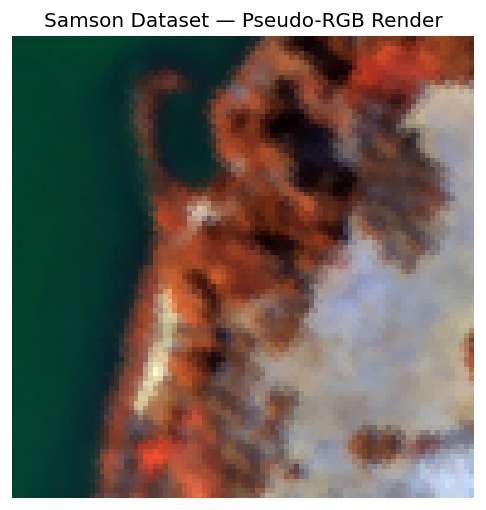

In [4]:
# Extract raw cube (H, W, L)
cube_samson = dataset_samson.get_image_cube().squeeze(0).permute(1, 2, 0).numpy()

# Pick bands for False-Color composite (approx Red, Green, Blue range)
rgb_samson = create_rgb_composite(cube_samson, 100, 50, 10)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_samson)
plt.title("Samson Dataset — Pseudo-RGB Render")
plt.axis('off')
plt.show()

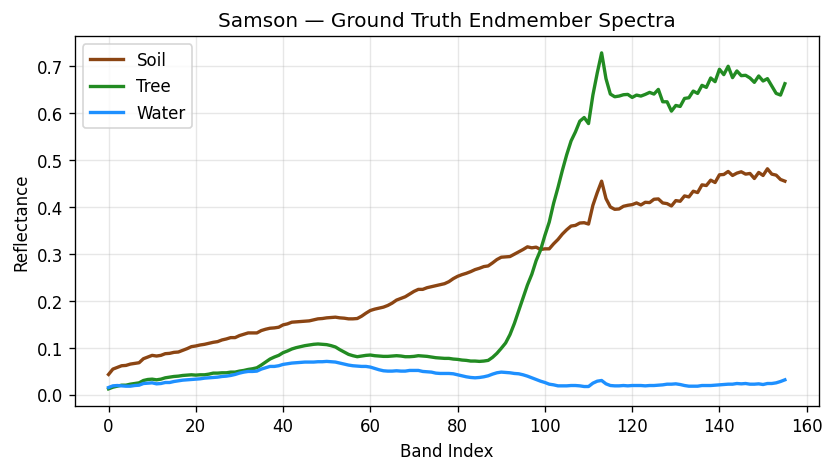

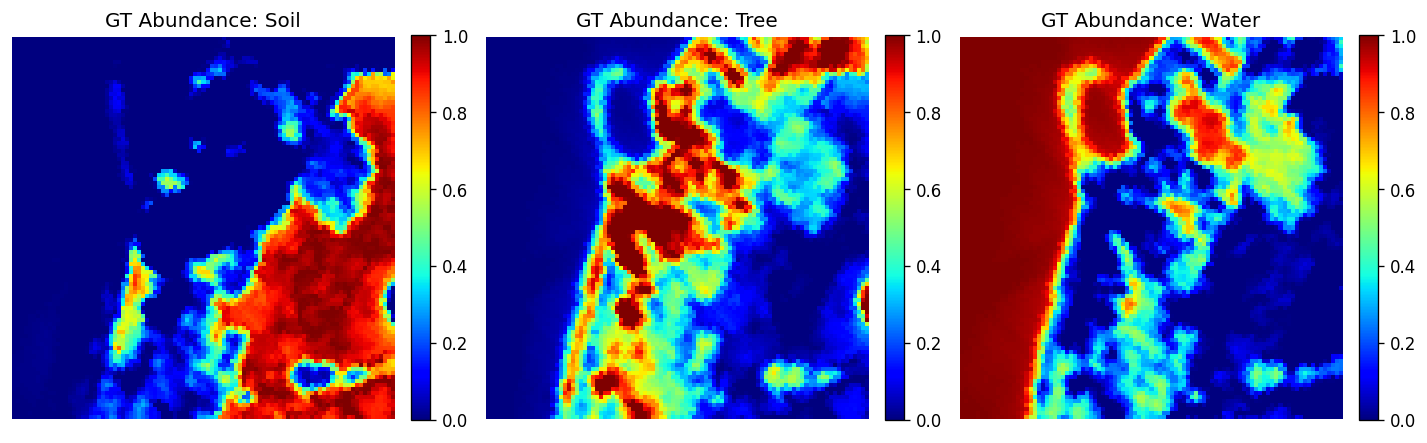

In [5]:
E_samson = dataset_samson.get_endmembers().numpy()
A_samson = dataset_samson.get_abundance_cube().numpy()
EM_NAMES_SAMSON = ['Soil', 'Tree', 'Water']

# 1. Plot Ground Truth Endmembers (Spectra)
fig, ax = plt.subplots(figsize=(8, 4))
bands = np.arange(E_samson.shape[0])
colors = ['#8B4513', '#228B22', '#1E90FF']
for i in range(E_samson.shape[1]):
    ax.plot(bands, E_samson[:, i], label=EM_NAMES_SAMSON[i], color=colors[i], linewidth=2)
ax.set_title("Samson — Ground Truth Endmember Spectra")
ax.set_xlabel("Band Index")
ax.set_ylabel("Reflectance")
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot Ground Truth Abundances (Spatial distribution)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i in range(3):
    im = axes[i].imshow(A_samson[:, :, i], cmap='jet', vmin=0, vmax=1)
    axes[i].set_title(f"GT Abundance: {EM_NAMES_SAMSON[i]}")
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 2. Apex Dataset Exploration

In [6]:
dataset_apex = HyperspectralDataset('apex', data_dir='./data/raw', device='cpu')
print(dataset_apex)

HyperspectralDataset(name='apex', pixels=12100, bands=285, endmembers=4, spatial=110x110)


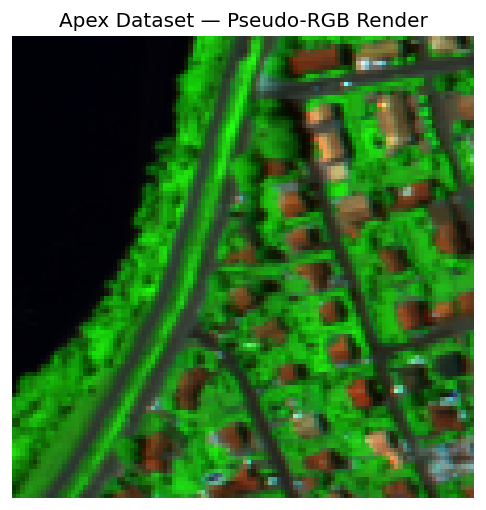

In [7]:
# Extract raw cube (H, W, L)
cube_apex = dataset_apex.get_image_cube().squeeze(0).permute(1, 2, 0).numpy()

# Pick bands for False-Color composite 
rgb_apex = create_rgb_composite(cube_apex, 200, 100, 30)

plt.figure(figsize=(5, 5))
plt.imshow(rgb_apex)
plt.title("Apex Dataset — Pseudo-RGB Render")
plt.axis('off')
plt.show()

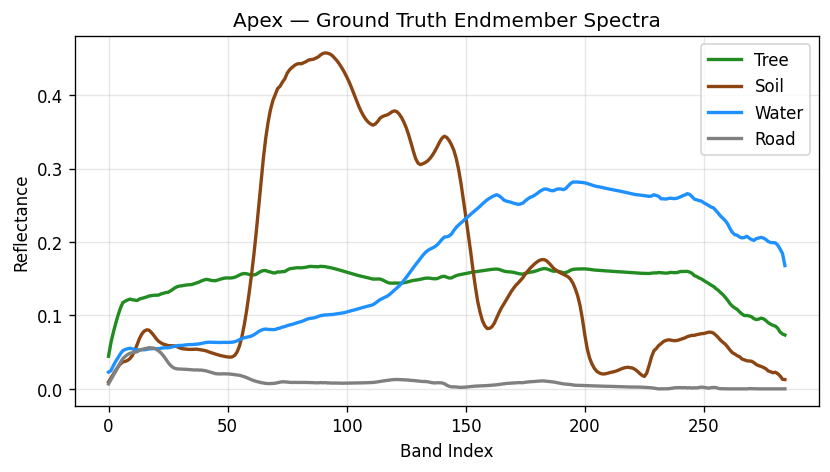

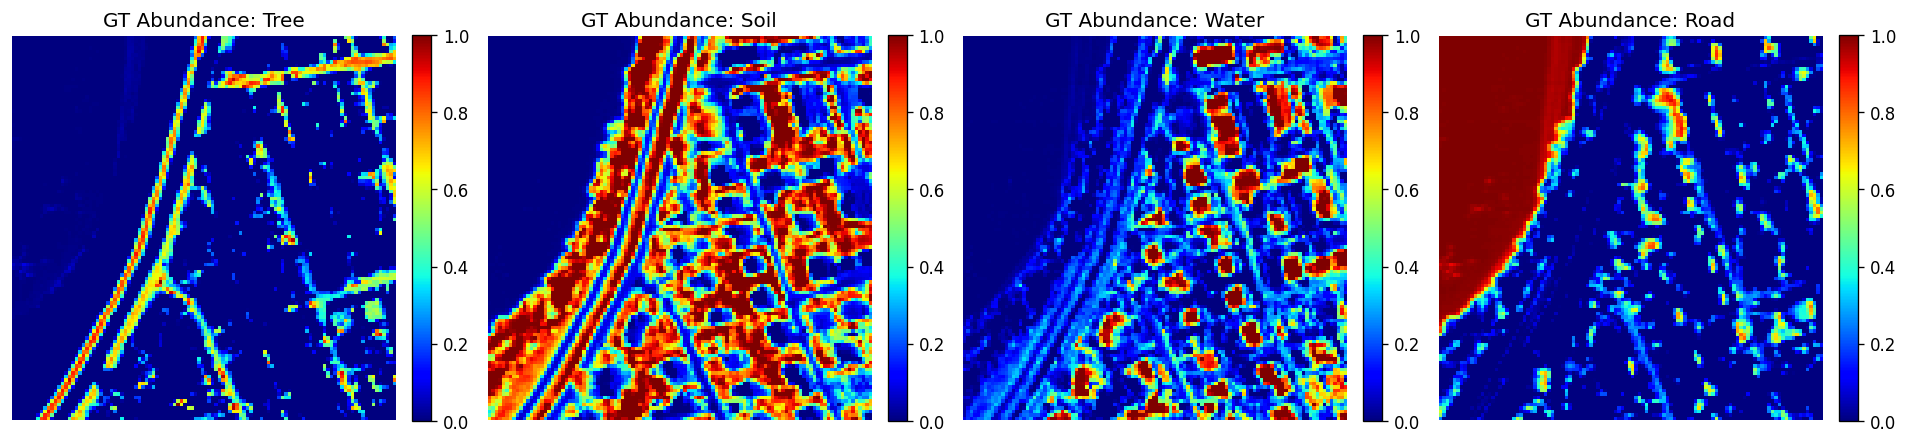

In [8]:
E_apex = dataset_apex.get_endmembers().numpy()
A_apex = dataset_apex.get_abundance_cube().numpy()
EM_NAMES_APEX = ['Tree', 'Soil', 'Water', 'Road']

# 1. Plot Ground Truth Endmembers (Spectra)
fig, ax = plt.subplots(figsize=(8, 4))
bands = np.arange(E_apex.shape[0])
colors = ['#228B22', '#8B4513', '#1E90FF', '#808080']
for i in range(E_apex.shape[1]):
    ax.plot(bands, E_apex[:, i], label=EM_NAMES_APEX[i], color=colors[i], linewidth=2)
ax.set_title("Apex — Ground Truth Endmember Spectra")
ax.set_xlabel("Band Index")
ax.set_ylabel("Reflectance")
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 2. Plot Ground Truth Abundances (Spatial distribution)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    im = axes[i].imshow(A_apex[:, :, i], cmap='jet', vmin=0, vmax=1)
    axes[i].set_title(f"GT Abundance: {EM_NAMES_APEX[i]}")
    axes[i].axis('off')
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Conclusion

Both datasets provide rich spectral information and validated spatial ground truths. 
In the next steps (Notebook 02 & 03), we use these structures to train and evaluate the deep learning architectures.